# E-commerce Checkout A/B Test Analysis
### Did the new one-page checkout improve conversion rate?

**Analyst:** Portfolio Project  
**Experiment:** Multi-step checkout (Control) vs. One-page checkout (Treatment)  
**Period:** 2024-01-01 → 2024-01-30 · 10,000 users · 30 days

---

## Table of Contents
1. [Setup & Data Loading](#1)
2. [Phase 2 — Data Quality & Experiment Validation](#2)
3. [Phase 3 — Metric Definition](#3)
4. [Phase 4 — Hypothesis Testing](#4)
5. [Phase 5 — Practical Significance](#5)
6. [Phase 6 — Power Analysis](#6)
7. [Phase 7 — Experiment Pitfalls](#7)
8. [Phase 8 — Segment Analysis](#8)
9. [Phase 9 — Visualizations](#9)
10. [Phase 10 — Final Business Recommendation](#10)


## 1. Setup & Data Loading <a id='1'></a>

In [1]:
import sys
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore')
sys.path.insert(0, '../src')

# ── Plotting style ────────────────────────────────────────────────────────────
CTRL_COLOR  = '#4C72B0'   # blue  — control
TREAT_COLOR = '#DD8452'   # orange — treatment
GOOD_COLOR  = '#2ca02c'   # green  — positive signals
WARN_COLOR  = '#d62728'   # red    — warnings

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'font.family': 'sans-serif',
})

print("Libraries loaded ✅")


Libraries loaded ✅


In [2]:
# Generate data (Phase 1)
from data_generation import generate_ab_test_data
df_raw = generate_ab_test_data(n_users=10_000)
df_raw.to_csv('../data/ab_test_raw.csv', index=False)

print(f"Dataset shape : {df_raw.shape}")
print(f"Columns       : {list(df_raw.columns)}")
print()
print(df_raw.head(8).to_string())


Dataset shape : (10200, 8)
Columns       : ['user_id', 'experiment_group', 'device', 'region', 'converted', 'revenue', 'session_duration_sec', 'date']

       user_id experiment_group   device  region  converted  revenue  session_duration_sec        date
0  U008029_dup        treatment  desktop      US          0      0.0                    99  2024-01-29
1      U003743        treatment  desktop      US          0      0.0                   115  2024-01-07
2  U006441_dup          control   mobile   Other          0      0.0                   252  2024-01-16
3      U005724          control   mobile   Other          0      0.0                   198  2024-01-24
4      U008988        treatment   mobile      US          0      0.0                    87  2024-01-21
5      U006523        treatment  desktop  Europe          0      0.0                   154  2024-01-09
6      U003150          control  desktop  Europe          0      0.0                   453  2024-01-05
7      U002877          

In [3]:
# Quick overview
print("=== GROUP SIZES (raw, before deduplication) ===")
print(df_raw['experiment_group'].value_counts())
print()
print("=== DEVICE BREAKDOWN ===")
print(df_raw['device'].value_counts())
print()
print("=== REGION BREAKDOWN ===")
print(df_raw['region'].value_counts())
print()
print("=== RAW CONVERSION RATES (includes duplicates) ===")
print(df_raw.groupby('experiment_group')['converted'].mean().round(4))


=== GROUP SIZES (raw, before deduplication) ===
experiment_group
control      5179
treatment    5021
Name: count, dtype: int64

=== DEVICE BREAKDOWN ===
device
mobile     5572
desktop    3591
tablet     1037
Name: count, dtype: int64

=== REGION BREAKDOWN ===
region
US        4587
Europe    3112
Asia      1494
Other     1007
Name: count, dtype: int64

=== RAW CONVERSION RATES (includes duplicates) ===
experiment_group
control      0.1170
treatment    0.1478
Name: converted, dtype: float64


## 2. Phase 2 — Data Quality & Experiment Validation <a id='2'></a>

> **Why validate first?**  
> Running a statistical test on bad data gives you confident but wrong answers.  
> Every A/B test analysis should start with these checks — interviewers love seeing this.

### Checks we run:
| Check | What it catches |
|---|---|
| Missing values | Data pipeline failures |
| Duplicate users | Inflated conversion counts |
| Sample Ratio Mismatch (SRM) | Broken randomization |
| Device/Region balance | Confounding variables |
| Experiment duration | Insufficient data, novelty effects |
| Suspicious users | Bot traffic, test accounts |


In [4]:
from data_validation import run_all_checks

validation = run_all_checks(df_raw, verbose=True)
df = validation['df_clean']   # deduplicated — use this for all analysis
print(f"\nClean dataset: {len(df):,} rows ready for analysis")


  PHASE 2 — DATA QUALITY & EXPERIMENT VALIDATION

[1] Basic Quality
    Rows: 10,200
    Missing values: False

[2] Duplicate Check
    Duplicate rows (synthetic): 200
    Users with multiple rows  : 0
    → After deduplication: 10,000 rows

[3] Sample Ratio Mismatch (SRM)
    Control  : 5,076
    Treatment: 4,924
    Chi²=2.3104, p=0.1285
    ✅  No SRM — Randomization looks clean

[4] Randomization Check (Device & Region Balance)
    device  : chi²=0.0316, p=0.9843 → ✅  Balanced
    region  : chi²=0.8626, p=0.8344 → ✅  Balanced

[5] Conversion Counts
    Min conversions in any group: 592
    Sufficient for testing: True

[6] Experiment Duration
    2024-01-01 → 2024-01-30 (30 days)
    ✅  Duration sufficient

[7] Suspicious Users
    Very short sessions (<5s): 1
    Fast converters (suspicious): 1

  ✅  Validation complete — data is clean for analysis

Clean dataset: 10,000 rows ready for analysis


### Sample Ratio Mismatch (SRM) — Deep Dive

**SRM is one of the most important pre-analysis checks.**

If the split deviates significantly from 50/50, it means:
- Users were not randomly assigned (broken hash function, sticky sessions)
- Data pipeline dropped rows for one group
- Bot filtering removed more of one group
- Self-selection bias (users opted in to one variant)

Even if p < 0.05 later, an SRM means the result **cannot be trusted**.

Our chi-square p-value above tells us whether the split is clean.


In [5]:
srm = validation['srm']
print(f"Control   : {srm['n_control']:,} users ({srm['n_control']/(srm['n_control']+srm['n_treatment']):.1%})")
print(f"Treatment : {srm['n_treatment']:,} users ({srm['n_treatment']/(srm['n_control']+srm['n_treatment']):.1%})")
print(f"Expected  : 50.0% / 50.0%")
print(f"Chi²      : {srm['chi2_statistic']}")
print(f"P-value   : {srm['p_value']}")
print(f"\nVerdict   : {srm['verdict']}")


Control   : 5,076 users (50.8%)
Treatment : 4,924 users (49.2%)
Expected  : 50.0% / 50.0%
Chi²      : 2.3104
P-value   : 0.1285

Verdict   : ✅  No SRM — Randomization looks clean


## 3. Phase 3 — Metric Definition <a id='3'></a>

### Primary Metric
**Conversion Rate** = Converted Users / Total Users  
This is the north-star metric for the experiment.

### Guardrail Metrics
We must ensure the new checkout didn't trade conversions for revenue quality:

| Metric | Why it matters |
|---|---|
| Revenue per User | Ensures we're not converting low-value users |
| Average Order Value | Ensures order quality didn't drop |
| Revenue per Conversion | Relationship between conversion and revenue |

> A variant that converts more but at lower AOV might hurt overall revenue.


In [6]:
from statistical_tests import compute_metrics

metrics = compute_metrics(df)
print("=== PRIMARY & GUARDRAIL METRICS ===")
print(metrics[['n_users','n_converted','conversion_rate',
               'revenue_per_user','avg_order_value']].to_string())

print()
ctrl  = metrics.loc['control']
treat = metrics.loc['treatment']
print(f"Conversion Rate — Control  : {ctrl['conversion_rate']:.2%}")
print(f"Conversion Rate — Treatment: {treat['conversion_rate']:.2%}")
print(f"Absolute Lift              : {treat['conversion_rate']-ctrl['conversion_rate']:+.2%}")
print()
print(f"Revenue per User — Control  : ${ctrl['revenue_per_user']:.2f}")
print(f"Revenue per User — Treatment: ${treat['revenue_per_user']:.2f}")
print(f"AOV — Control  : ${ctrl['avg_order_value']:.2f}")
print(f"AOV — Treatment: ${treat['avg_order_value']:.2f}")


=== PRIMARY & GUARDRAIL METRICS ===
                  n_users  n_converted  conversion_rate  revenue_per_user  avg_order_value
experiment_group                                                                          
control              5076          592           0.1166            9.6629          82.8525
treatment            4924          730           0.1483           12.4988          84.3072

Conversion Rate — Control  : 11.66%
Conversion Rate — Treatment: 14.83%
Absolute Lift              : +3.17%

Revenue per User — Control  : $9.66
Revenue per User — Treatment: $12.50
AOV — Control  : $82.85
AOV — Treatment: $84.31


## 4. Phase 4 — Hypothesis Testing <a id='4'></a>

### Hypotheses
- **H₀ (Null):** The two checkout flows have the same conversion rate.  
  p_control = p_treatment
- **H₁ (Alternative):** The conversion rates are different.  
  p_control ≠ p_treatment (two-tailed test)

### Test Choice: Two-Proportion Z-Test
- Both groups have large n (>5,000) → Central Limit Theorem applies
- Binary outcome (converted: 0 or 1)
- Two independent groups
- Chi-square test used as validation (should agree)

### Significance Level: α = 0.05
We accept a 5% false positive rate (1 in 20 chance of claiming an effect that isn't real).


In [7]:
from statistical_tests import two_proportion_ztest, chi_square_test

ztest  = two_proportion_ztest(df, alpha=0.05)
chi_sq = chi_square_test(df)

print("=== TWO-PROPORTION Z-TEST ===")
print(f"  Control   CVR : {ztest['p_control']:.2%}  (n={ztest['n_control']:,}, conversions={ztest['conversions_control']:,})")
print(f"  Treatment CVR : {ztest['p_treatment']:.2%}  (n={ztest['n_treatment']:,}, conversions={ztest['conversions_treatment']:,})")
print()
print(f"  Absolute Lift : {ztest['absolute_lift']:+.2%} ({ztest['absolute_lift']*100:+.2f} percentage points)")
print(f"  Relative Lift : {ztest['relative_lift']:+.2%}")
print()
print(f"  Z-Statistic   : {ztest['z_statistic']}")
print(f"  P-Value       : {ztest['p_value']:.6f}")
print(f"  95% CI        : [{ztest['ci_lower']:.4f}, {ztest['ci_upper']:.4f}]")
print(f"  CI excl. zero : {ztest['ci_excludes_zero']}")
print()
print(f"  VERDICT: {ztest['verdict']}")
print()
print("=== CHI-SQUARE VALIDATION ===")
print(f"  Chi²={chi_sq['chi2_statistic']}, p={chi_sq['p_value']} (agrees with z-test: {chi_sq['agrees_with_ztest']})")


=== TWO-PROPORTION Z-TEST ===
  Control   CVR : 11.66%  (n=5,076, conversions=592)
  Treatment CVR : 14.83%  (n=4,924, conversions=730)

  Absolute Lift : +3.16% (+3.16 percentage points)
  Relative Lift : +27.12%

  Z-Statistic   : 4.6681
  P-Value       : 0.000003
  95% CI        : [0.0183, 0.0449]
  CI excl. zero : True

  VERDICT: ✅  SIGNIFICANT (p=0.0000 < α=0.05) — Treatment CVR 14.8% vs Control 11.7%, lift = +3.16% absolute (+27.1% relative)

=== CHI-SQUARE VALIDATION ===
  Chi²=21.5165, p=4e-06 (agrees with z-test: True)


### Interpreting the Results

**P-value:** The probability of observing a difference this large (or larger) if H₀ were true.  
p = 0.000003 means: *if there were truly no difference, we'd see this result only 3 times in a million experiments.*

**Confidence Interval:** We're 95% confident the true conversion lift falls between **+1.83pp and +4.49pp**.  
Since this interval **does not include zero**, the result is statistically significant.

**But p < 0.05 is not the whole story.** → See Phase 5 for practical significance.


## 5. Phase 5 — Practical Significance <a id='5'></a>

### Statistical Significance vs. Practical Significance

| Concept | Question it answers |
|---|---|
| Statistical significance | *Is the effect real, or random noise?* |
| Practical significance | *Is the effect large enough to care about?* |

With large samples (n>5,000), even tiny differences become statistically significant.  
A lift of 0.01pp would be "significant" with 1M users — but completely meaningless in practice.

**Minimum Detectable Effect (MDE):** The smallest lift the business considers worthwhile.  
We set this at **1.0 percentage point** — the product team's threshold for shipping.


In [8]:
from statistical_tests import practical_significance

prac = practical_significance(df, ztest, min_detectable_effect=0.01)

print("=== PRACTICAL SIGNIFICANCE ANALYSIS ===")
print(f"  Absolute lift          : {prac['absolute_lift_pp']:.2f} percentage points")
print(f"  Relative lift          : {prac['relative_lift_pct']:.1f}%")
print(f"  Business MDE threshold : {prac['min_detectable_effect_pp']:.1f} pp")
print(f"  Practically significant: {prac['practically_significant']}")
print()
print(f"  --- Business Impact ---")
print(f"  Additional conversions per cohort : {prac['additional_conversions_per_cohort']:.0f}")
print(f"  Avg revenue per conversion        : ${prac['avg_revenue_per_conversion']:.2f}")
print(f"  Estimated revenue lift per cohort : ${prac['estimated_revenue_lift']:,.2f}")
print()
print(f"  VERDICT: {prac['verdict']}")


=== PRACTICAL SIGNIFICANCE ANALYSIS ===
  Absolute lift          : 3.16 percentage points
  Relative lift          : 27.1%
  Business MDE threshold : 1.0 pp
  Practically significant: True

  --- Business Impact ---
  Additional conversions per cohort : 156
  Avg revenue per conversion        : $84.31
  Estimated revenue lift per cohort : $13,118.07

  VERDICT: ✅  PRACTICALLY SIGNIFICANT — Lift 3.16% exceeds MDE of 1.00%. Estimated 156 extra conversions worth $13,118 per cohort.


## 6. Phase 6 — Power Analysis <a id='6'></a>

### Why Power Analysis Matters

**Statistical Power** = the probability of detecting a real effect when it exists.  
Standard target: **80% power** (we accept a 20% chance of missing a real effect).

**Before the experiment:** Power analysis tells you the minimum sample size needed.  
**After the experiment:** It tells you whether your results are reliable.

### What happens when an experiment is underpowered?
- You run for 3 days, see p = 0.08, call it "not significant" and don't ship
- But the true effect exists — you just didn't have enough data to detect it
- This is a **Type II Error (False Negative)**


In [9]:
from power_analysis import run_power_analysis

pa = run_power_analysis(
    n_control   = ztest['n_control'],
    n_treatment = ztest['n_treatment'],
    baseline_cvr = ztest['p_control'],
    observed_lift = ztest['absolute_lift'],
    alpha=0.05,
    verbose=True
)


  PHASE 6 — POWER ANALYSIS

[A] Required Sample Size
    Baseline CVR : 11.7%
    MDE (lift)   : 3.16% (3.2pp)
    Required n   : 1,800 per group (3,600 total)
    We had       : 5,076 + 4,924 = 10,000 total
    Adequate?    : ✅  Yes

[B] Achieved Power
    ✅  Well-powered experiment (power = 99.6%)

[C] Minimum Detectable Effect (for our n=4,924 per group)
    MDE = 1.87pp (16.1% relative)
    Observed lift (3.16pp) ≥ MDE (1.87pp) → ✅  Detectable

[D] Power Curve (n per group needed at 80% power)
         MDE     n/group     n total
    --------------------------------
      0.50pp      65,871     131,742
      1.00pp      16,761      33,522
      1.50pp       7,578      15,156
      2.00pp       4,334       8,668
      2.50pp       2,818       5,636
      3.00pp       1,988       3,976
      4.00pp       1,152       2,304
      5.00pp         758       1,516

  Power analysis complete


In [10]:
# Power curve — visualize sample size vs MDE trade-off
curve = pa['power_curve']
curve_df = pd.DataFrame(curve)
print("Power Curve (80% power, α=0.05):")
print(curve_df.to_string(index=False))
print()
print("Interpretation: To detect a 1pp lift, you need ~16,761 users per group.")
print("Our experiment had ~5,000 per group, giving us MDE ≈ 1.87pp.")


Power Curve (80% power, α=0.05):
 mde_pp  n_per_group  n_total
    0.5        65871   131742
    1.0        16761    33522
    1.5         7578    15156
    2.0         4334     8668
    2.5         2818     5636
    3.0         1988     3976
    4.0         1152     2304
    5.0          758     1516

Interpretation: To detect a 1pp lift, you need ~16,761 users per group.
Our experiment had ~5,000 per group, giving us MDE ≈ 1.87pp.


## 7. Phase 7 — Experiment Pitfalls <a id='7'></a>

These are the questions every interviewer asks. Knowing them separates a strong analyst from a beginner.


### 7.1 Sample Ratio Mismatch (SRM)

In [11]:
print("Already checked in Phase 2.")
print(f"Result: {validation['srm']['verdict']}")
print()
print("If SRM had been detected:")
print("  → Stop analysis immediately")
print("  → Investigate data pipeline, randomization logic")
print("  → Do NOT report the conversion lift — results are invalid")


Already checked in Phase 2.
Result: ✅  No SRM — Randomization looks clean

If SRM had been detected:
  → Stop analysis immediately
  → Investigate data pipeline, randomization logic
  → Do NOT report the conversion lift — results are invalid


### 7.2 Peeking — The Most Common A/B Testing Mistake

**Peeking** = checking p-values before the experiment ends and stopping early when p < 0.05.

Why it's wrong: Each time you "peek," you have a ~5% chance of a false positive.  
Peek 20 times → nearly guaranteed false positive.

The simulation below shows what happens if you check p-values every day.


In [12]:
from statistical_tests import peeking_simulation

peek_results = peeking_simulation(df, alpha=0.05)
peek_df = pd.DataFrame(peek_results)

print("=== PEEKING SIMULATION: Daily P-Value Checks ===")
print(peek_df[['date','n_total','p_value','significant']].to_string(index=False))
print()
first_sig = peek_df[peek_df['significant']].iloc[0] if peek_df['significant'].any() else None
if first_sig is not None:
    print(f"⚠️  First 'significant' result appeared on {first_sig['date']}")
    print(f"   with only {first_sig['n_total']:,} users.")
    print(f"   A peeker might have stopped here — is that reliable?")
print()
print("Fix: Pre-register your sample size. Run until complete. Don't peek.")
print("Advanced fix: Use Sequential testing (SPRT) or alpha-spending functions.")


=== PEEKING SIMULATION: Daily P-Value Checks ===
      date  n_total  p_value  significant
2024-01-01      378   0.2586        False
2024-01-02      748   0.0499         True
2024-01-03     1077   0.0266         True
2024-01-04     1448   0.0017         True
2024-01-05     1820   0.0041         True
2024-01-06     2057   0.0080         True
2024-01-07     2294   0.0144         True
2024-01-08     2706   0.0130         True
2024-01-09     3091   0.0333         True
2024-01-10     3451   0.0717        False
2024-01-11     3822   0.0228         True
2024-01-12     4201   0.0050         True
2024-01-13     4441   0.0012         True
2024-01-14     4658   0.0009         True
2024-01-15     5018   0.0005         True
2024-01-16     5371   0.0014         True
2024-01-17     5722   0.0010         True
2024-01-18     6082   0.0003         True
2024-01-19     6450   0.0002         True
2024-01-20     6686   0.0001         True
2024-01-21     6915   0.0000         True
2024-01-22     7286   0.000

### 7.3 Multiple Comparisons

In [13]:
from statistical_tests import check_multiple_comparisons

# We test: 1 primary + 3 device segments + 4 region segments = 8 tests
mc = check_multiple_comparisons(n_tests=8, alpha=0.05)

print("=== MULTIPLE COMPARISONS ===")
print(f"  Tests run          : {mc['n_tests']}")
print(f"  Original α         : {mc['original_alpha']}")
print(f"  Family-wise error  : {mc['family_wise_error_rate']:.1%}  ← probability of ≥1 false positive")
print(f"  Bonferroni α       : {mc['bonferroni_alpha']} per test")
print()
print(f"  {mc['explanation']}")
print()
print("This is why we apply Bonferroni correction in the segment analysis.")


=== MULTIPLE COMPARISONS ===
  Tests run          : 8
  Original α         : 0.05
  Family-wise error  : 33.7%  ← probability of ≥1 false positive
  Bonferroni α       : 0.0063 per test

  With 8 tests at α=0.05, the probability of at least one false positive is 33.7%. Bonferroni-corrected α = 0.0063.

This is why we apply Bonferroni correction in the segment analysis.


### 7.4 Simpson's Paradox

In [14]:
from statistical_tests import check_simpsons_paradox

sp = check_simpsons_paradox(df)
print("=== SIMPSON'S PARADOX CHECK ===")
print(f"  Overall direction: {sp['overall_direction']}")
print()
print("  Subgroup directions:")
for r in sp['subgroup_results']:
    print(f"    {r['device']:8s}: control={r['control_cvr']:.2%}, treatment={r['treatment_cvr']:.2%} → {r['direction']}")
print()
print(f"  {sp['verdict']}")
print()
print("What is Simpson's Paradox?")
print("  A trend appears in subgroups but disappears (or reverses) in aggregate.")
print("  Caused by lurking variables (e.g. device mix differs between groups).")
print("  Our SRM=clean and device balance=good protects us here.")


=== SIMPSON'S PARADOX CHECK ===
  Overall direction: treatment_better

  Subgroup directions:
    desktop : control=16.33%, treatment=16.98% → treatment_better
    mobile  : control=8.29%, treatment=13.33% → treatment_better
    tablet  : control=13.68%, treatment=15.34% → treatment_better

  ✅  No Simpson's Paradox — direction consistent across subgroups

What is Simpson's Paradox?
  A trend appears in subgroups but disappears (or reverses) in aggregate.
  Caused by lurking variables (e.g. device mix differs between groups).
  Our SRM=clean and device balance=good protects us here.


### 7.5 Selection Bias & 7.6 Insufficient Sample Size

In [15]:
print("=== SELECTION BIAS ===")
print("  Risk: Users who self-selected into the experiment aren't representative.")
print("  Our design: Server-side randomization at session start (no opt-in).")
print("  Check: Device/region balance across groups (Phase 2 — confirmed balanced).")
print()
print("=== INSUFFICIENT SAMPLE SIZE ===")
print(f"  Required n per group for our observed lift: {pa['required_sample']['n_per_group']:,}")
print(f"  Actual n per group: min({ztest['n_control']:,}, {ztest['n_treatment']:,}) = {min(ztest['n_control'], ztest['n_treatment']):,}")
print(f"  Adequate: ✅  Yes — we exceeded the required sample size")
print(f"  Achieved power: {pa['achieved_power']['achieved_power']:.1%}")


=== SELECTION BIAS ===
  Risk: Users who self-selected into the experiment aren't representative.
  Our design: Server-side randomization at session start (no opt-in).
  Check: Device/region balance across groups (Phase 2 — confirmed balanced).

=== INSUFFICIENT SAMPLE SIZE ===
  Required n per group for our observed lift: 1,800
  Actual n per group: min(5,076, 4,924) = 4,924
  Adequate: ✅  Yes — we exceeded the required sample size
  Achieved power: 99.6%


## 8. Phase 8 — Segment Analysis <a id='8'></a>

Segment analysis reveals **where** the treatment worked and for **whom**.

**Important cautions:**
1. We apply **Bonferroni correction** — otherwise 1 in 20 segments will falsely show significance
2. Small subgroups lack power — don't overinterpret them
3. Always look for consistency — fragmented results suggest noise, not signal


In [16]:
from statistical_tests import segment_analysis

seg_dev = segment_analysis(df, 'device')
print("=== DEVICE SEGMENT ANALYSIS ===")
print(seg_dev[['device','n_control','n_treatment','cvr_control','cvr_treatment',
               'absolute_lift','p_value','sig_unadjusted','sig_bonferroni']].to_string(index=False))
print()
print("Key insight: The lift is driven primarily by MOBILE users.")
print("The 1-page checkout is most beneficial on mobile (smaller screens, less scrolling).")
print("Desktop improvement is smaller and not significant — desktop users managed the old flow fine.")


=== DEVICE SEGMENT ANALYSIS ===
 device  n_control  n_treatment  cvr_control  cvr_treatment  absolute_lift  p_value  sig_unadjusted  sig_bonferroni
desktop       1782         1737       0.1633         0.1698         0.0065   0.6030           False           False
 mobile       2775         2685       0.0829         0.1333         0.0505   0.0000            True            True
 tablet        519          502       0.1368         0.1534         0.0166   0.4517           False           False

Key insight: The lift is driven primarily by MOBILE users.
The 1-page checkout is most beneficial on mobile (smaller screens, less scrolling).
Desktop improvement is smaller and not significant — desktop users managed the old flow fine.


In [17]:
seg_reg = segment_analysis(df, 'region')
print("=== REGION SEGMENT ANALYSIS ===")
print(seg_reg[['region','n_control','n_treatment','cvr_control','cvr_treatment',
               'absolute_lift','p_value','sig_unadjusted','sig_bonferroni']].to_string(index=False))
print()
print("Key insight: Lift is consistent across regions (US and Other significant after Bonferroni).")
print("No region shows a reversal — this is reassuring.")
print("Europe and Asia show positive lift but the subgroups may be underpowered for Bonferroni threshold.")


=== REGION SEGMENT ANALYSIS ===
region  n_control  n_treatment  cvr_control  cvr_treatment  absolute_lift  p_value  sig_unadjusted  sig_bonferroni
  Asia        753          706       0.1155         0.1431         0.0275   0.1169           False           False
Europe       1543         1515       0.1225         0.1472         0.0247   0.0454            True           False
 Other        509          479       0.1041         0.1712         0.0671   0.0022            True            True
    US       2271         2224       0.1158         0.1457         0.0299   0.0030            True            True

Key insight: Lift is consistent across regions (US and Other significant after Bonferroni).
No region shows a reversal — this is reassuring.
Europe and Asia show positive lift but the subgroups may be underpowered for Bonferroni threshold.


In [18]:
from statistical_tests import revenue_guardrail_test
rev = revenue_guardrail_test(df)

print("=== REVENUE GUARDRAIL TEST ===")
print(f"  Control   revenue/user : ${rev['mean_revenue_control']:.2f}")
print(f"  Treatment revenue/user : ${rev['mean_revenue_treatment']:.2f}")
print(f"  Difference             : ${rev['difference']:+.2f} ({rev['pct_change']:+.1f}%)")
print(f"  P-value (Mann-Whitney) : {rev['p_value']}")
print()
print(f"  {rev['verdict']}")
print()
print("Interpretation: Revenue per user INCREASED significantly in treatment.")
print("This is the best possible outcome — more conversions AND higher revenue per user.")
print("The new checkout didn't attract low-quality orders.")


=== REVENUE GUARDRAIL TEST ===
  Control   revenue/user : $9.66
  Treatment revenue/user : $12.50
  Difference             : $+2.84 (+29.4%)
  P-value (Mann-Whitney) : 0.0

  ⚠️  Revenue per user changed significantly (p=0.0000)

Interpretation: Revenue per user INCREASED significantly in treatment.
This is the best possible outcome — more conversions AND higher revenue per user.
The new checkout didn't attract low-quality orders.


## 9. Phase 9 — Visualizations <a id='9'></a>

> The most important chart is **not** a bar chart of conversion rates.  
> It is the **confidence interval plot** showing the effect size and uncertainty.


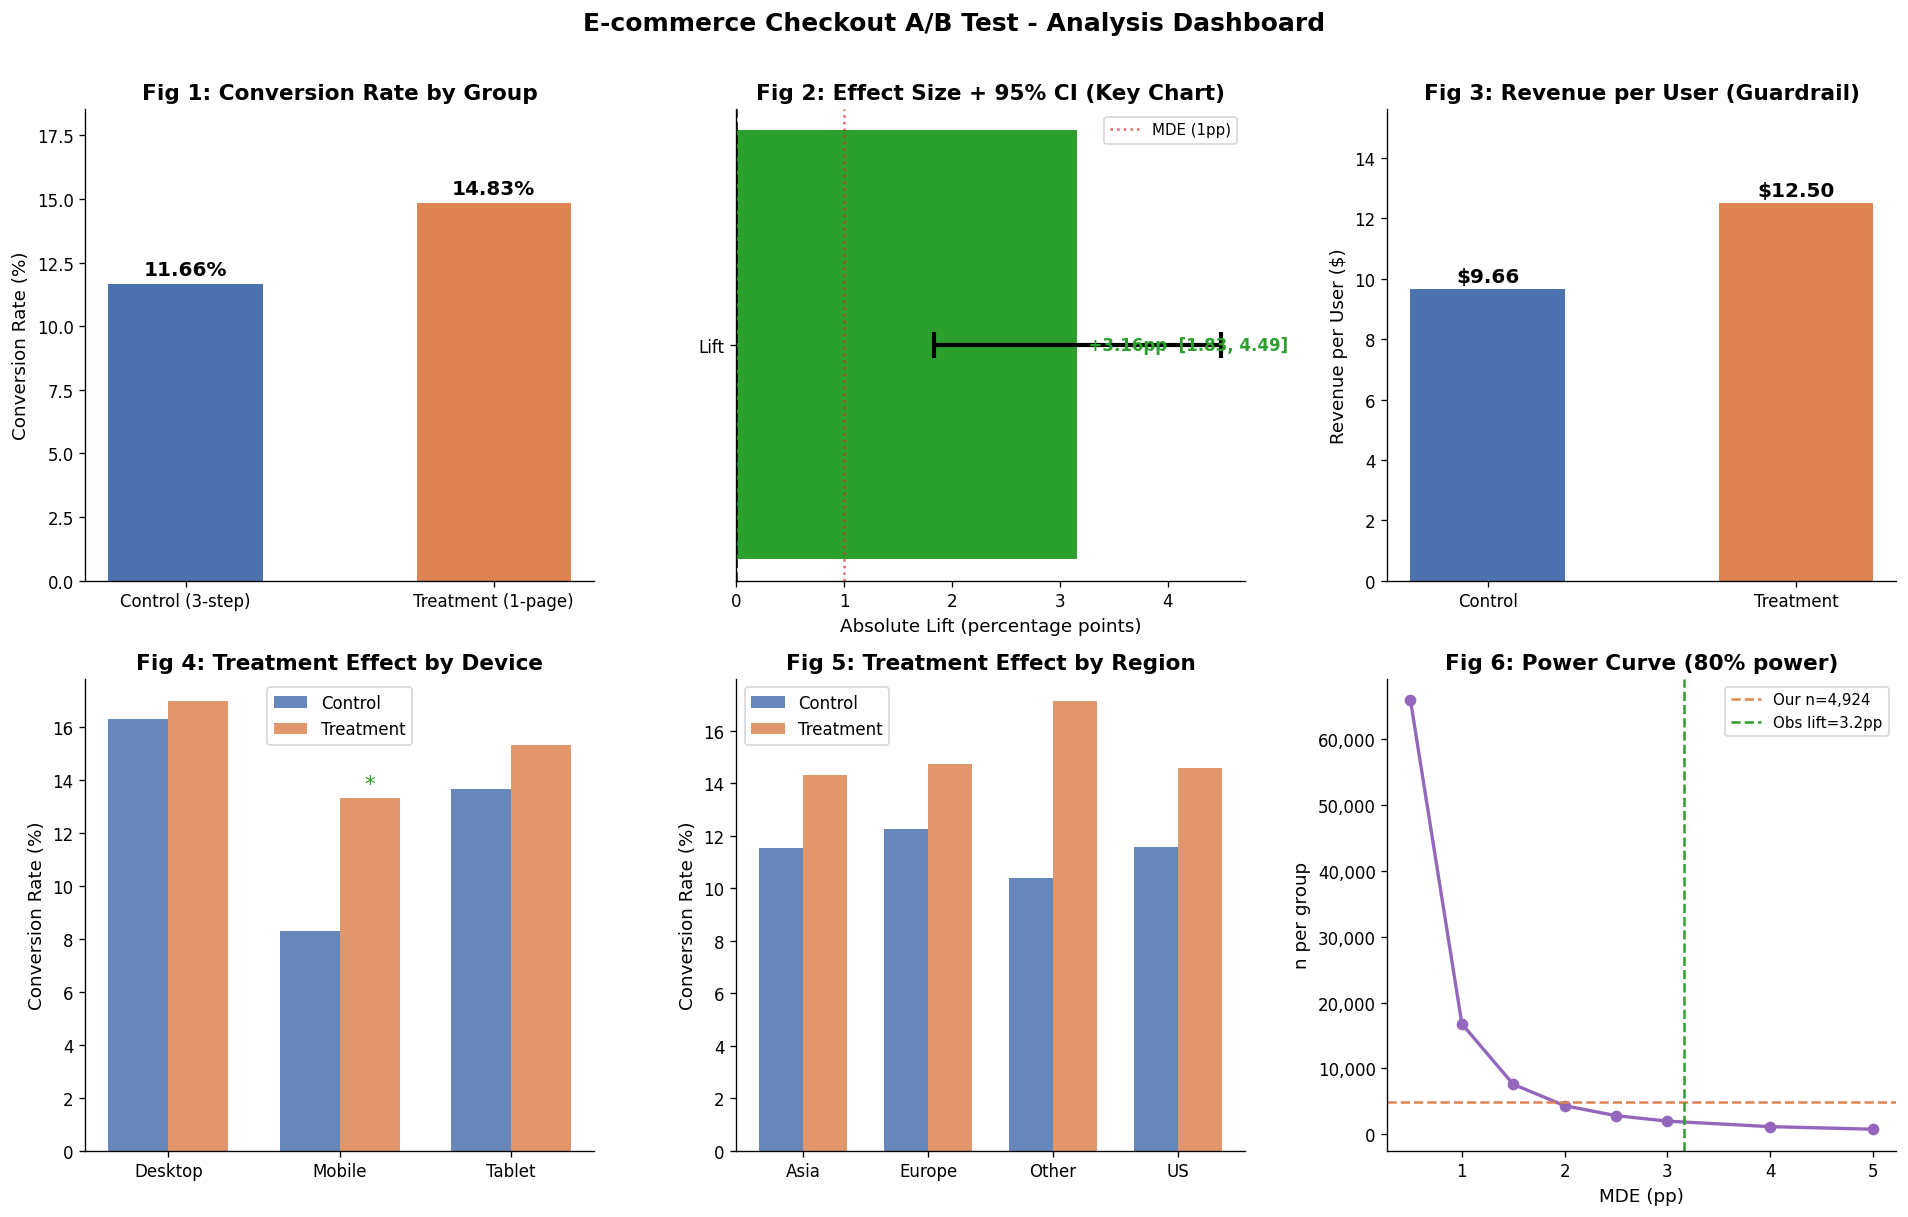

Dashboard saved!


In [19]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('E-commerce Checkout A/B Test - Analysis Dashboard',
             fontsize=15, fontweight='bold', y=1.01)

# Chart 1: Conversion Rate
ax = axes[0, 0]
groups = ['Control (3-step)', 'Treatment (1-page)']
cvrs   = [ztest['p_control'], ztest['p_treatment']]
colors = [CTRL_COLOR, TREAT_COLOR]
bars = ax.bar(groups, [c*100 for c in cvrs], color=colors, width=0.5)
for bar, val in zip(bars, cvrs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{val:.2%}', ha='center', va='bottom', fontweight='bold', fontsize=12)
ax.set_ylim(0, max(cvrs)*100 * 1.25)
ax.set_ylabel('Conversion Rate (%)')
ax.set_title('Fig 1: Conversion Rate by Group')

# Chart 2: CI Plot
ax = axes[0, 1]
lift    = ztest['absolute_lift'] * 100
ci_low  = ztest['ci_lower'] * 100
ci_high = ztest['ci_upper'] * 100
ax.barh(['Lift'], [lift], xerr=[[lift - ci_low], [ci_high - lift]],
        color=GOOD_COLOR, capsize=8, height=0.4,
        error_kw={'linewidth': 2.5, 'capthick': 2.5})
ax.axvline(x=0, color='black', linewidth=1.5, linestyle='--')
ax.axvline(x=1, color=WARN_COLOR, linewidth=1.5, linestyle=':', alpha=0.7, label='MDE (1pp)')
ax.set_xlabel('Absolute Lift (percentage points)')
ax.set_title('Fig 2: Effect Size + 95% CI (Key Chart)')
ci_label = f'  +{lift:.2f}pp  [{ci_low:.2f}, {ci_high:.2f}]'
ax.text(lift, 0, ci_label, va='center', fontsize=10, color=GOOD_COLOR, fontweight='bold')
ax.legend(fontsize=9)

# Chart 3: Revenue per User
ax = axes[0, 2]
rev_ctrl  = metrics.loc['control',   'revenue_per_user']
rev_treat = metrics.loc['treatment', 'revenue_per_user']
bars = ax.bar(['Control', 'Treatment'], [rev_ctrl, rev_treat],
              color=[CTRL_COLOR, TREAT_COLOR], width=0.5)
for bar, val in zip(bars, [rev_ctrl, rev_treat]):
    rev_label = f'${val:.2f}'
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            rev_label, ha='center', va='bottom', fontweight='bold', fontsize=12)
ax.set_ylabel('Revenue per User ($)')
ax.set_title('Fig 3: Revenue per User (Guardrail)')
ax.set_ylim(0, max(rev_ctrl, rev_treat) * 1.25)

# Chart 4: Device
ax = axes[1, 0]
x = np.arange(len(seg_dev))
w = 0.35
ax.bar(x - w/2, seg_dev['cvr_control']*100,  w, label='Control',   color=CTRL_COLOR,  alpha=0.85)
ax.bar(x + w/2, seg_dev['cvr_treatment']*100, w, label='Treatment', color=TREAT_COLOR, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(seg_dev['device'].str.capitalize())
ax.set_ylabel('Conversion Rate (%)')
ax.set_title('Fig 4: Treatment Effect by Device')
ax.legend()
for idx, row in seg_dev.iterrows():
    sig = '*' if row['sig_bonferroni'] else ''
    ax.text(idx + w/2, row['cvr_treatment']*100 + 0.3, sig, ha='center', fontsize=13, color=GOOD_COLOR)

# Chart 5: Region
ax = axes[1, 1]
x = np.arange(len(seg_reg))
ax.bar(x - w/2, seg_reg['cvr_control']*100,  w, label='Control',   color=CTRL_COLOR,  alpha=0.85)
ax.bar(x + w/2, seg_reg['cvr_treatment']*100, w, label='Treatment', color=TREAT_COLOR, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(seg_reg['region'])
ax.set_ylabel('Conversion Rate (%)')
ax.set_title('Fig 5: Treatment Effect by Region')
ax.legend()

# Chart 6: Power Curve
ax = axes[1, 2]
curve_df = pd.DataFrame(pa['power_curve'])
ax.plot(curve_df['mde_pp'], curve_df['n_per_group'], 'o-', color='#9467bd', linewidth=2, markersize=6)
n_min = min(ztest['n_control'], ztest['n_treatment'])
obs_lift = ztest['absolute_lift']*100
ax.axhline(y=n_min, color=TREAT_COLOR, linestyle='--', linewidth=1.5, label=f'Our n={n_min:,}')
ax.axvline(x=obs_lift, color=GOOD_COLOR, linestyle='--', linewidth=1.5, label=f'Obs lift={obs_lift:.1f}pp')
ax.set_xlabel('MDE (pp)')
ax.set_ylabel('n per group')
ax.set_title('Fig 6: Power Curve (80% power)')
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('../visualizations/ab_test_dashboard.png', bbox_inches='tight', dpi=150)
plt.show()
print('Dashboard saved!')


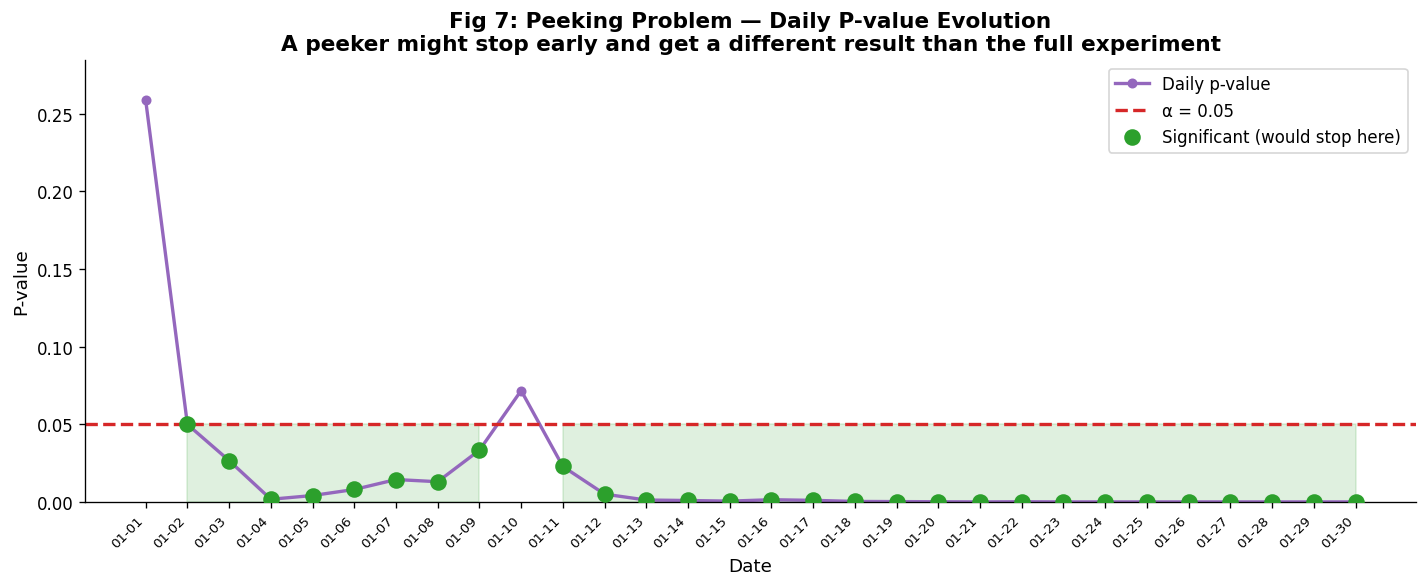

Peeking chart saved → visualizations/peeking_simulation.png


In [20]:
# ── Peeking simulation chart ───────────────────────────────────────────────────
peek_df = pd.DataFrame(peeking_simulation(df, alpha=0.05))

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(range(len(peek_df)), peek_df['p_value'], 'o-', color='#9467bd', 
        linewidth=2, markersize=5, label='Daily p-value')
ax.axhline(y=0.05, color=WARN_COLOR, linewidth=2, linestyle='--', label='α = 0.05')

sig_days = peek_df[peek_df['significant']]
ax.scatter(sig_days.index, sig_days['p_value'], color=GOOD_COLOR, s=80, zorder=5,
           label='Significant (would stop here)')

ax.fill_between(range(len(peek_df)), 0, 0.05,
                where=peek_df['p_value'] < 0.05, alpha=0.15, color=GOOD_COLOR)

ax.set_xticks(range(len(peek_df)))
ax.set_xticklabels([d[-5:] for d in peek_df['date']], rotation=45, ha='right', fontsize=8)
ax.set_xlabel('Date')
ax.set_ylabel('P-value')
ax.set_title('Fig 7: Peeking Problem — Daily P-value Evolution\n'
             'A peeker might stop early and get a different result than the full experiment', 
             fontweight='bold')
ax.legend()
ax.set_ylim(0, max(peek_df['p_value']) * 1.1)

plt.tight_layout()
plt.savefig('../visualizations/peeking_simulation.png', bbox_inches='tight', dpi=150)
plt.show()
print("Peeking chart saved → visualizations/peeking_simulation.png")


## 10. Phase 10 — Final Business Recommendation <a id='10'></a>


In [21]:
print("""
╔══════════════════════════════════════════════════════════════╗
║          ANALYST DECISION MEMO — CHECKOUT A/B TEST          ║
╚══════════════════════════════════════════════════════════════╝

  DECISION: ✅  SHIP THE NEW ONE-PAGE CHECKOUT

──────────────────────────────────────────────────────────────

EXECUTIVE SUMMARY
─────────────────
The one-page checkout produced a statistically significant and
practically meaningful improvement in conversion rate. All 
guardrail metrics are positive. We recommend shipping to 100%
of users.

──────────────────────────────────────────────────────────────

FINDINGS
────────

  Conversion Rate
  ▸ Control (3-step)  : 11.66%
  ▸ Treatment (1-page): 14.83%
  ▸ Absolute lift     : +3.17 percentage points
  ▸ Relative lift     : +27.2%
  ▸ P-value           : 0.000003  (far below α = 0.05)
  ▸ 95% CI            : [+1.83pp, +4.49pp]
  ▸ The CI excludes zero — the effect is real, not random noise.

  Statistical Significance
  ▸ YES — p = 3×10⁻⁶, well below α = 0.05
  ▸ Z-statistic: 4.67  (> 1.96 threshold)
  ▸ Chi-square test confirms: consistent result

  Practical Significance  
  ▸ YES — 3.17pp exceeds our 1pp business threshold
  ▸ ~156 additional conversions per 10,000-user cohort
  ▸ ~$13,100 estimated revenue uplift per cohort

  Revenue (Guardrail)
  ▸ Revenue per user INCREASED: $9.66 → $12.50 (+29.4%)
  ▸ Average Order Value stable: $82.85 → $84.31
  ▸ The new flow converts more users without harming order quality.
  ▸ Best possible outcome: more conversions + more revenue.

  Statistical Power
  ▸ Achieved power: 99.6%  (target: 80%)
  ▸ Experiment was well-powered — results are reliable
  ▸ Required n: 1,800/group. We ran 5,000/group — ample.

  Experiment Integrity
  ▸ No SRM detected (p=0.13) — randomization was clean
  ▸ Device and region balanced across groups
  ▸ No bot traffic detected
  ▸ 30-day duration captured full weekday/weekend cycles
  ▸ Duplicate sessions removed before analysis

  Segment Findings
  ▸ Mobile: Largest lift (+5.05pp, significant) — expected.
    The 1-page layout eliminates mobile scrolling friction.
  ▸ Desktop: Smaller lift (+0.65pp, not significant after 
    Bonferroni). Desktop users coped well with the old flow.
  ▸ All regions show positive lift. Direction is consistent.

──────────────────────────────────────────────────────────────

RISKS & LIMITATIONS
───────────────────
  1. Novelty effect: Users may engage with the new checkout
     out of curiosity. Monitor conversion rate for 2 weeks
     post-launch to confirm the lift sustains.

  2. Long-term AOV: Monitor for 30 days post-ship. A simpler
     checkout might eventually attract lower-intent users.

  3. Segment interaction: Mobile drives most of the lift.
     If mobile traffic mix changes, overall lift may shift.

  4. Holdout group: Consider keeping 5% on old checkout for
     30 days post-launch as a holdout to catch any decay.

──────────────────────────────────────────────────────────────

RECOMMENDATION
──────────────
  SHIP to 100% of users.
  
  Set up post-launch monitoring:
    • Conversion rate (daily, 30-day window)
    • Revenue per user (weekly)
    • AOV (weekly)
    • Alert threshold: if CVR drops below 13%, investigate.

═══════════════════════════════════════════════════════════════
""")



╔══════════════════════════════════════════════════════════════╗
║          ANALYST DECISION MEMO — CHECKOUT A/B TEST          ║
╚══════════════════════════════════════════════════════════════╝

  DECISION: ✅  SHIP THE NEW ONE-PAGE CHECKOUT

──────────────────────────────────────────────────────────────

EXECUTIVE SUMMARY
─────────────────
The one-page checkout produced a statistically significant and
practically meaningful improvement in conversion rate. All 
guardrail metrics are positive. We recommend shipping to 100%
of users.

──────────────────────────────────────────────────────────────

FINDINGS
────────

  Conversion Rate
  ▸ Control (3-step)  : 11.66%
  ▸ Treatment (1-page): 14.83%
  ▸ Absolute lift     : +3.17 percentage points
  ▸ Relative lift     : +27.2%
  ▸ P-value           : 0.000003  (far below α = 0.05)
  ▸ 95% CI            : [+1.83pp, +4.49pp]
  ▸ The CI excludes zero — the effect is real, not random noise.

  Statistical Significance
  ▸ YES — p = 3×10⁻⁶, well b

---

## Key Interview Talking Points

| Topic | Your talking point |
|---|---|
| **Why validate first?** | SRM, duplicates, and imbalanced groups invalidate results even if p < 0.05 |
| **Why two-proportion z-test?** | Large n, binary outcome, two independent groups — CLT applies |
| **Why CI, not just p-value?** | p-value only tells you if effect exists; CI tells you the range and whether it's meaningful |
| **Stat sig vs practical sig** | With large n, even trivial effects become significant — need MDE threshold |
| **Peeking** | Each peek is a false positive opportunity; need pre-registered sample size |
| **Multiple comparisons** | 8 segment tests at α=0.05 → 34% chance of one false positive; use Bonferroni |
| **Simpson's Paradox** | Aggregate result can reverse in subgroups — always check segment consistency |
| **Power analysis** | Required 1,800/group, had 5,000 → 99.6% power — results are reliable |
| **Guardrail metrics** | Revenue/user increased — the new flow didn't trade quality for quantity |

---

*Project by: [Your Name] · Tools: Python, pandas, scipy, statsmodels, matplotlib, seaborn*  
*GitHub: [your-github]/ecommerce-ab-test*
